# Exploratory Data Analysis

The objective of this notebook is to explore the cleaned movie dataset and investigate how movie runtime relates to other variables such as release year, genres, ratings, popularity, and revenue.

Before performing the analysis, the runtime column will be validated to ensure that only reliable observations are included.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

## Load Clean Dataset

In [3]:
data = pd.read_csv('data/interim.csv', low_memory=False)

## Dataset Overview

In [4]:
data.shape

(44977, 20)

In [5]:
data.head()

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
0,30000000.0,862.0,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,1995-10-30,373554033.0,81.0,Toy Story,7.7,5415.0,['Toy Story Collection'],"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America'],['English'],1995.0,1990.0
1,65000000.0,8844.0,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,1995-12-15,262797249.0,104.0,Jumanji,6.9,2413.0,NaN,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America'],"['English', 'Français']",1995.0,1990.0
2,NaN,15602.0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,1995-12-22,NaN,101.0,Grumpier Old Men,6.5,92.0,['Grumpy Old Men Collection'],"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America'],['English'],1995.0,1990.0
3,16000000.0,31357.0,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,1995-12-22,81452156.0,127.0,Waiting to Exhale,6.1,34.0,NaN,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America'],['English'],1995.0,1990.0
4,NaN,11862.0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,1995-02-10,76578911.0,106.0,Father of the Bride Part II,5.7,173.0,['Father of the Bride Collection'],['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America'],['English'],1995.0,1990.0


In [6]:
data.sample(5)

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
3708,NaN,27452.0,en,The Spiral Staircase,"In 1916, beautiful young mute Helen is a domes...",7.719019,/b1VZwHlpl8DVPvnuCyauNGGV8QJ.jpg,1946-02-06,NaN,83.0,The Spiral Staircase,6.6,46.0,NaN,"['Crime', 'Drama', 'Horror', 'Mystery', 'Thril...",['RKO Radio Pictures'],['United States of America'],['English'],1946.0,1940.0
23939,NaN,16091.0,en,Aftermath: Population Zero,Aftermath: Population Zero investigates what w...,1.328618,/bUSKh0ZwY70lydQvmF0F4FuCIw8.jpg,2008-03-09,NaN,90.0,Aftermath: Population Zero,6.7,11.0,NaN,"['Documentary', 'Science Fiction']",['Cream Productions'],['United States of America'],"['English', 'Deutsch']",2008.0,2000.0
264,NaN,32325.0,en,Mi Vida Loca,Mousie and Sad Girl are childhood best friends...,1.788829,/uEzbxMuT2d1KNR0KEfQncN7IUq2.jpg,1994-06-08,NaN,92.0,Mi Vida Loca,5.7,9.0,NaN,"['Crime', 'Drama']","['Channel Four Films', 'Cineville', 'Home Box ...",['United States of America'],"['English', 'Español']",1994.0,1990.0
11930,NaN,1127.0,es,Princesas,"Set in Spain, the story is about friendship an...",2.923859,/aHg2IOpslBZGiW7IipGCGmect00.jpg,2005-09-02,NaN,113.0,Princesses,6.9,24.0,NaN,['Drama'],"['Reposado Producciones', 'Antena 3 Televisión...",['Spain'],['Español'],2005.0,2000.0
24033,60000000.0,170687.0,en,The Boxtrolls,An orphaned boy raised by underground creature...,11.563909,/82BWSf1NfCm18ZJtAOIym1QRd24.jpg,2014-09-10,108255770.0,97.0,The Boxtrolls,6.6,689.0,NaN,"['Animation', 'Comedy', 'Family', 'Fantasy']",['Laika Entertainment'],['United States of America'],['English'],2014.0,2010.0


In [7]:
# Convert columns from string to list
import ast

columns_to_convert = ['collection', 'genre_names', 'company_names',
                       'country_names', 'language_names']

for col in columns_to_convert:
    data[col] = data[col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x)

# Verify the result
# Create a DataFrame to Verify the result
col_verify = pd.DataFrame({
    'Column': columns_to_convert,
    'Sample Value':  [data[col].iloc[0] for col in columns_to_convert],
    'Sample_Dtype': [type(data[col].iloc[0]) for col in columns_to_convert],
})
col_verify

,Column,Sample Value,Sample_Dtype
0,collection,[Toy Story Collection],<class 'list'>
1,genre_names,"[Animation, Comedy, Family]",<class 'list'>
2,company_names,[Pixar Animation Studios],<class 'list'>
3,country_names,[United States of America],<class 'list'>
4,language_names,[English],<class 'list'>


## Runtime Validation

Before exploring runtime patterns, we first verify that the runtime column is reliable for analysis. This includes identifying missing values, suspicious runtimes, and extreme observations. Only after validating the data quality will we proceed with the exploratory analysis.

In [8]:
runtime = data['runtime']
runtime.describe()

count    43231.000000
mean        97.531794
std         34.711792
min          1.000000
25%         86.000000
50%         95.000000
75%        107.000000
max       1256.000000
Name: runtime, dtype: float64

In [9]:
print(runtime.isna().sum())
print(runtime.isna().mean() * 100)

1746
3.8819841252195566


In [33]:
runtime_data = data.dropna(subset=["runtime"]).copy()

In [10]:
runtime.sort_values().head(10)

44961    1.0
44931    1.0
25030    1.0
19885    1.0
44237    1.0
39579    1.0
36248    1.0
36247    1.0
28376    1.0
40793    1.0
Name: runtime, dtype: float64

In [11]:
runtime.dropna().sort_values().tail(10)

34364     840.0
34429     840.0
19042     874.0
26486     877.0
27649     900.0
13885     925.0
13701     931.0
40543    1140.0
19837    1140.0
24003    1256.0
Name: runtime, dtype: float64

In [12]:
data.loc[
    data["runtime"] <= 10,
    ["title", "runtime", "release_year", "genre_names"]
].sort_values("runtime")

,title,runtime,release_year,genre_names
44961,The One-Man Band,1.0,1900.0,"[Fantasy, Action, Thriller]"
16165,The Four Troublesome Heads,1.0,1898.0,"[Comedy, Fantasy]"
16170,The Human Pyramid,1.0,1899.0,[Fantasy]
17236,Meat Love,1.0,1989.0,"[Comedy, Drama, Fantasy]"
17469,Edison Kinetoscopic Record of a Sneeze,1.0,1894.0,[Documentary]
...,...,...,...,...
38510,Multiple SIDosis,10.0,1970.0,NaN
38525,There Will Come Soft Rains,10.0,1984.0,"[Animation, Science Fiction]"
44658,Polygon,10.0,1977.0,[Animation]
44727,Rick and Morty: State of Georgia Vs. Denver Fe...,10.0,2016.0,"[Comedy, Crime]"


In [13]:
data.nlargest(
    20,
    "runtime"
)[["title", "runtime", "release_year", "genre_names"]]

,title,runtime,release_year,genre_names
24003,Centennial,1256.0,1978.0,"[Drama, History]"
19837,Jazz,1140.0,2001.0,[Documentary]
40543,Baseball,1140.0,1994.0,[Documentary]
13701,Berlin Alexanderplatz,931.0,1980.0,[Drama]
13885,Heimat: A Chronicle of Germany,925.0,1984.0,"[Drama, History]"
27649,The Story of Film: An Odyssey,900.0,2011.0,[Documentary]
26486,Taken,877.0,2002.0,[Science Fiction]
19042,The War,874.0,2007.0,"[Documentary, History, War]"
34364,The Roosevelts: An Intimate History,840.0,2014.0,"[History, Documentary]"
34429,Seventeen Moments in Spring,840.0,1973.0,"[Adventure, Drama, History, War]"


## Runtime Distribution
### Histogram

Now that the runtime column has been validated, we explore its overall distribution to understand the typical movie length and identify any notable patterns.

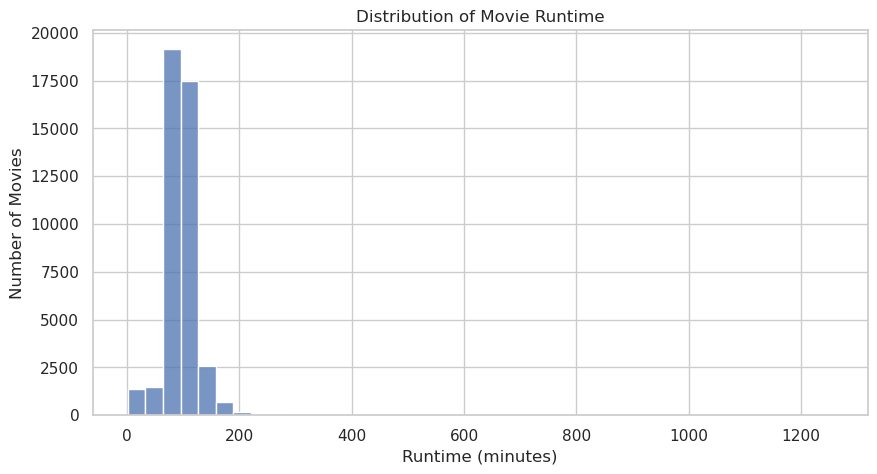

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(data=runtime_data, x="runtime", bins=40)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

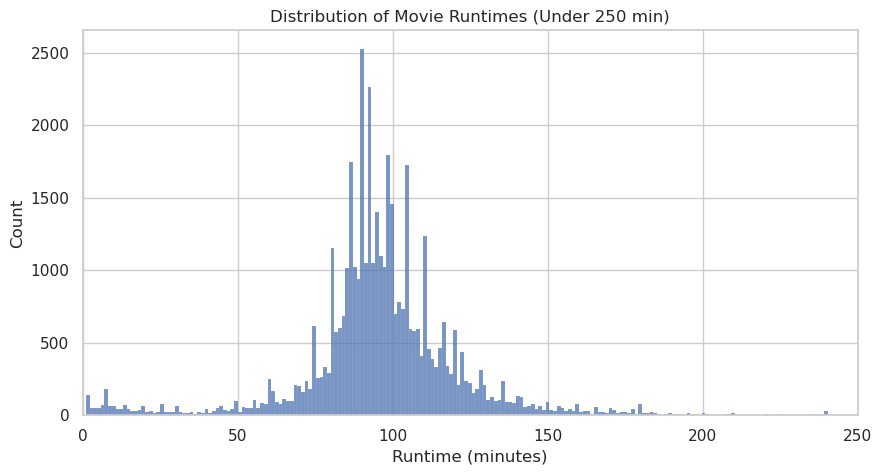

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=runtime_data,
    x="runtime",
    bins='auto'
)

plt.xlabel("Runtime (minutes)")
plt.title("Distribution of Movie Runtimes (Under 250 min)")
plt.xlim(0,250)

plt.show()

### Boxplot

A boxplot provides a compact summary of the runtime distribution and helps identify potential outliers.

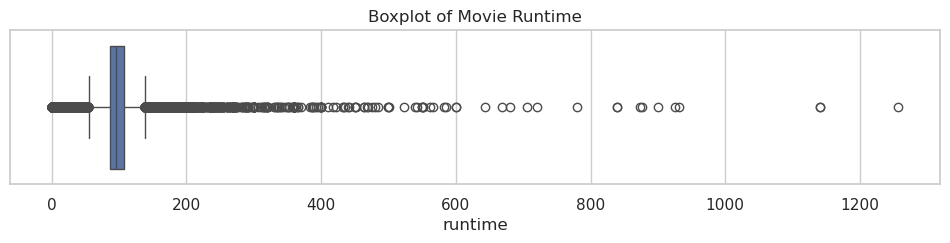

In [38]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="runtime"
)

plt.title("Boxplot of Movie Runtime")

plt.show()

In [17]:
# Count and mean of movies with runtime > 600
print('Count:', (data['runtime'] > 600).sum())
print('Mean:', data[data['runtime'] > 600]['runtime'].mean())

Count: 16
Mean: 870.0625


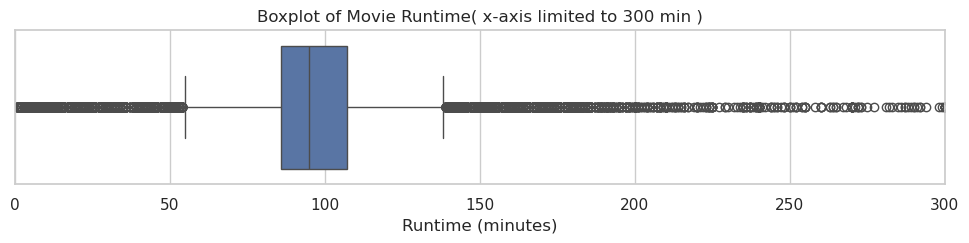

In [39]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="runtime"
)
plt.xlim(0,300)
plt.xlabel("Runtime (minutes)")
plt.title("Boxplot of Movie Runtime( x-axis limited to 300 min )")

plt.show()

### Histogram with Kernel Density Estimation (KDE)

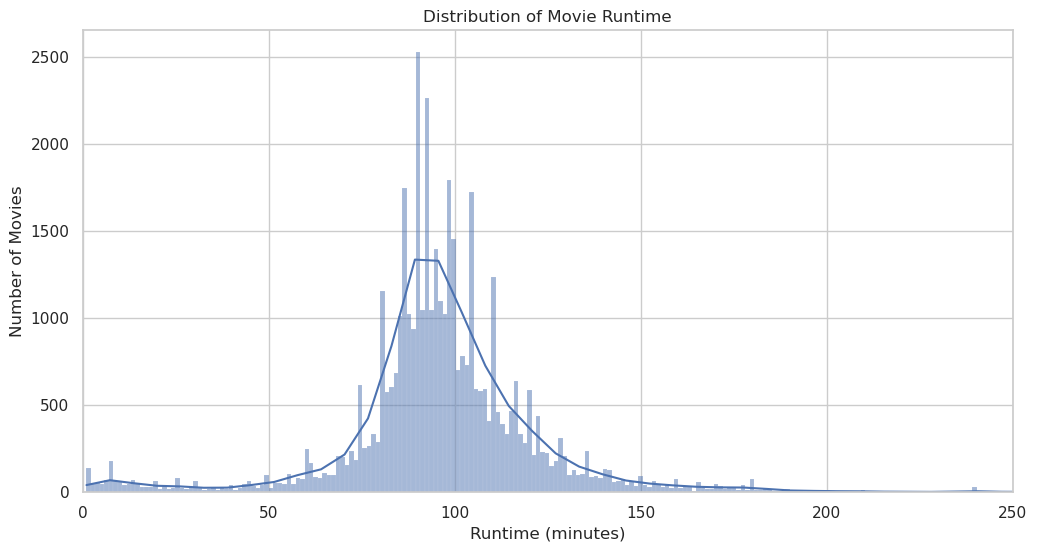

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=runtime_data,
    x="runtime",
    bins='auto',
    kde=True
)

plt.xlim(0, 250)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

The runtime distribution is unimodal, with a clear peak around 90–100 minutes. The distribution is right-skewed, indicating that while a small number of movies have exceptionally long runtimes, the vast majority fall between 80 and 120 minutes. This suggests that very long movies are rare and should be treated as exceptional cases rather than representative of the overall dataset.

### Runtime Threshold Analysis

In [45]:
threshold = [90, 120, 150, 180, 240]
summary = []

for t in threshold:
    summary.append({
        "Runtime > (min)" : t,
        "Movies" : (runtime_data['runtime'] > t).sum(),
        "Percentage" : (runtime_data['runtime'] > t).mean() * 100
    }) 

runtime_summary = pd.DataFrame(summary)
runtime_summary

,Runtime > (min),Movies,Percentage
0,90,26962,62.367283
1,120,4976,11.510259
2,150,1384,3.201406
3,180,517,1.195901
4,240,195,0.451065


Although nearly 60% of movies are longer than 90 minutes, only about 1.15% exceed three hours (180 minutes), indicating that extremely long movies are uncommon.

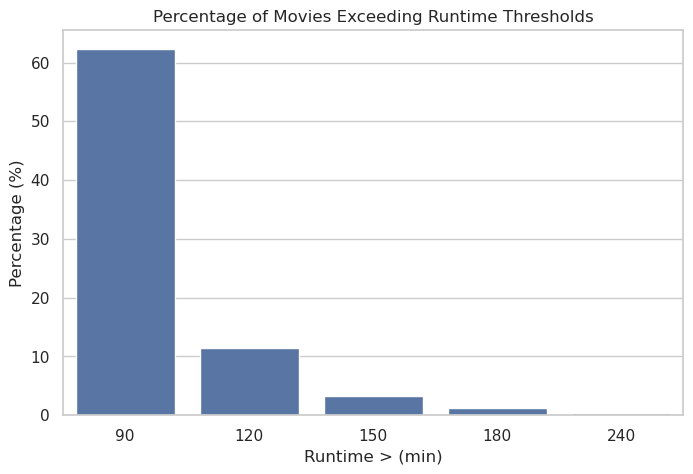

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=runtime_summary,
    x="Runtime > (min)",
    y="Percentage"
)

plt.title("Percentage of Movies Exceeding Runtime Thresholds")
plt.ylabel("Percentage (%)")

plt.show()

## Runtime Over Time
Has the average runtime of movies changed over time?

In [22]:
data["release_year"].describe()

count    44899.000000
mean      1991.819395
std         24.071299
min       1874.000000
25%       1978.000000
50%       2001.000000
75%       2010.000000
max       2017.000000
Name: release_year, dtype: float64

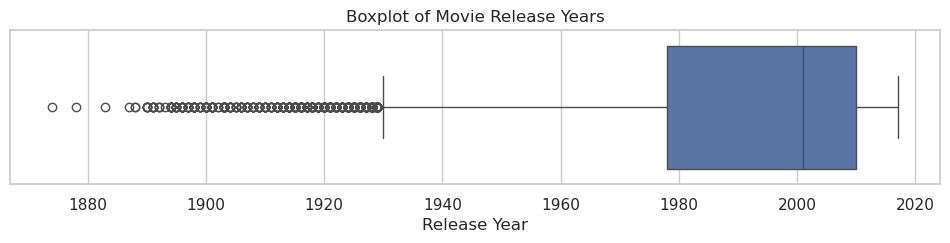

In [41]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=runtime_data,
    x="release_year"
)

plt.xlabel("Release Year")
plt.title("Boxplot of Movie Release Years")

plt.show()

In [24]:
data["release_year"].isnull().sum()

np.int64(78)

In [42]:
runtime_by_year = (
    runtime_data
    .groupby("release_year")["runtime"]
    .mean()
    .reset_index()
)

runtime_by_year.sample(10)

,release_year,runtime
92,1977.0,101.098101
112,1997.0,102.047923
2,1883.0,1.000000
66,1951.0,90.364583
121,2006.0,99.692371
128,2013.0,96.261015
57,1942.0,85.506944
49,1934.0,78.700730
56,1941.0,90.619048
122,2007.0,98.396346


In [43]:
movies_per_year = (
    runtime_data.groupby("release_year")
    .size()
    .reset_index(name="movie_count")
)

movies_per_year.sample(10)

,release_year,movie_count
69,1954.0,184
52,1937.0,152
20,1905.0,4
5,1890.0,5
11,1896.0,14
1,1878.0,1
116,2001.0,805
29,1914.0,19
98,1983.0,339
7,1892.0,3


In [27]:
valid_years = movies_per_year.loc[
    movies_per_year["movie_count"] >= 30,
    "release_year"
]

runtime_by_year_filtered = runtime_by_year[
    runtime_by_year["release_year"].isin(valid_years)
]

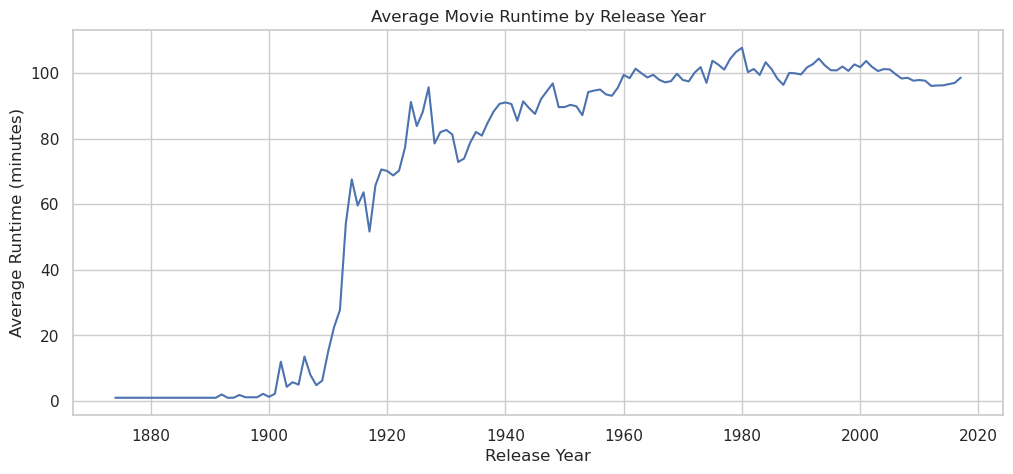

In [29]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=runtime_by_year,
    x="release_year",
    y="runtime"
)

plt.title("Average Movie Runtime by Release Year")
plt.ylabel("Average Runtime (minutes)")
plt.xlabel("Release Year")

plt.show()

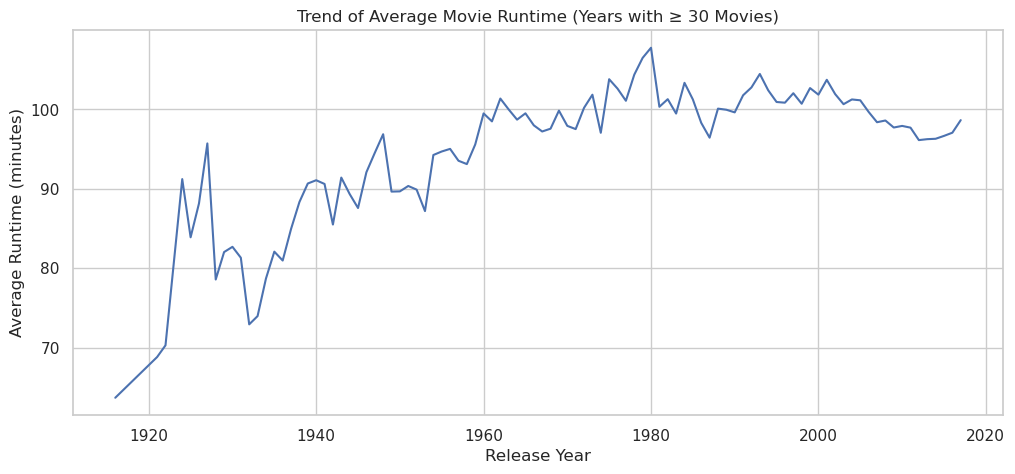

In [31]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=runtime_by_year_filtered,
    x="release_year",
    y="runtime"
)

plt.title("Trend of Average Movie Runtime (Years with ≥ 30 Movies)")
plt.ylabel("Average Runtime (minutes)")
plt.xlabel("Release Year")

plt.show()

## Runtime by Genre

To investigate whether movie runtime differs across genres, we compare the distribution and central tendency of runtime across movie genres.

In [ ]:
genre_data = runtime_data[
    ["title", "runtime", "genre_names"]
].explode("genre_names")

genre_data.head()

,title,runtime,genre_names
0,Toy Story,81.0,Animation
0,Toy Story,81.0,Comedy
0,Toy Story,81.0,Family
1,Jumanji,104.0,Adventure
1,Jumanji,104.0,Fantasy


Since a movie can belong to multiple genres, the `genre_names` column contains lists of genres. We use `explode()` to create one row for each movie-genre relationship, allowing us to analyze runtime separately for each genre.

In [100]:
print(genre_data["genre_names"].isna().sum())
print(genre_data["genre_names"].isna().mean() * 100)

1869
2.0755597014925375


In [101]:
genre_data = genre_data.dropna(
    subset=["genre_names"]
).copy()

In [102]:
genre_data["genre_names"]

0        Animation
0           Comedy
0           Family
1        Adventure
1          Fantasy
           ...    
44972       Family
44973        Drama
44974       Action
44974        Drama
44974     Thriller
Name: genre_names, Length: 88179, dtype: object

In [103]:
genre_counts = genre_data["genre_names"].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

total_movies = genre_counts['Count'].sum()
genre_counts['Percentage'] = (genre_counts['Count'] / total_movies * 100).round(2)

genre_counts

,Genre,Count,Percentage
0,Drama,19633,22.26
1,Comedy,12578,14.26
2,Thriller,7415,8.41
3,Romance,6536,7.41
4,Action,6425,7.29
5,Horror,4558,5.17
6,Crime,4205,4.77
7,Documentary,3728,4.23
8,Adventure,3416,3.87
9,Science Fiction,2968,3.37


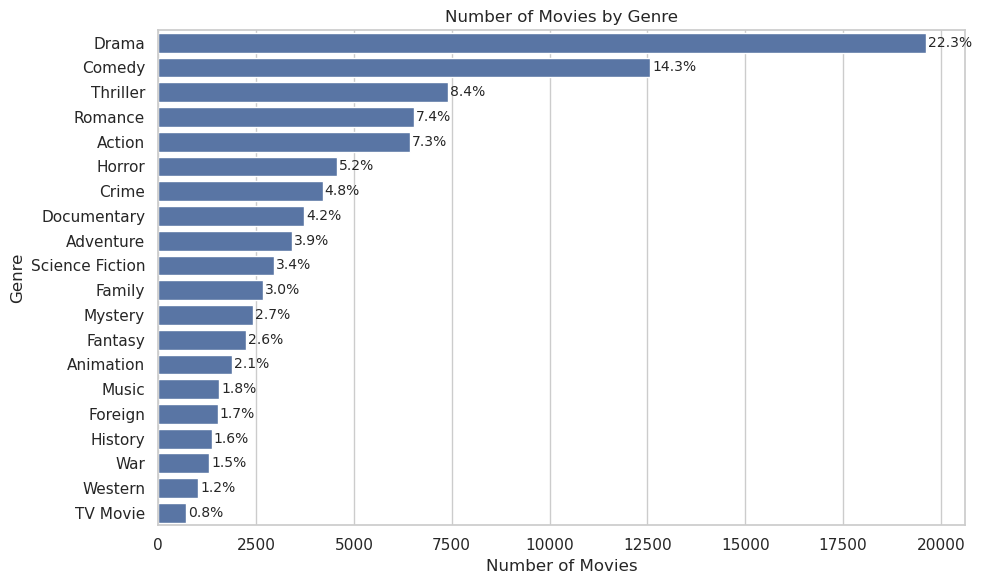

In [104]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=genre_counts,
    x='Count',
    y='Genre'
)

total = genre_counts['Count'].sum()
for i, row in genre_counts.iterrows():
    percent = (row['Count'] / total * 100).round(1)
    ax.text(row['Count'] + 50, i, f'{percent}%', va='center', fontsize=10)

plt.title("Number of Movies by Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### Runtime Comparison Across Genres

Before comparing runtime across genres, we examine the number of observations available for each genre. This helps us assess whether the group-level runtime statistics are based on sufficiently large samples.

In [105]:
genre_runtime = (
    genre_data
    .groupby("genre_names")["runtime"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

genre_runtime

,count,mean,median
genre_names,,,
History,1368,126.285819,114.0
War,1299,114.026174,106.0
Drama,19633,105.138288,100.0
Romance,6536,104.336291,100.0
Foreign,1522,105.009855,99.0
Crime,4205,101.563615,99.0
Adventure,3416,103.067037,98.0
Action,6425,102.707393,98.0
Music,1557,100.862556,98.0


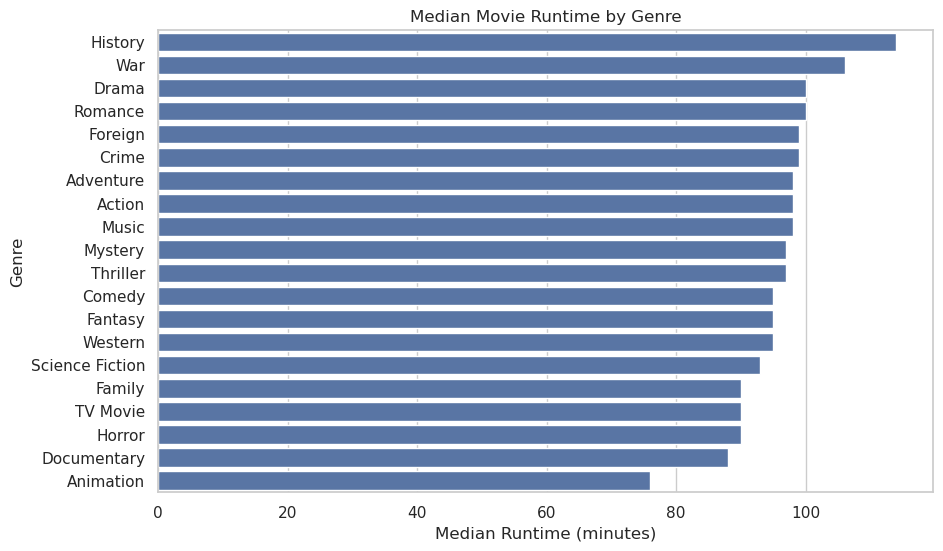

In [109]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_runtime,
    x="median",
    y=genre_runtime.index
)

plt.title("Median Movie Runtime by Genre")
plt.xlabel("Median Runtime (minutes)")
plt.ylabel("Genre")

plt.show()